In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import *


import torch
import torch.nn as nn   #신경망 층 들어있는 모듈
import torch.optim as optim #학습
from torch.utils.data import DataLoader, TensorDataset #배치 단위 데이터 공급자


# 자연어 처리를 위해 추가된 부분
import nltk # 자연어 처리 라이브러리 본체
from nltk.tokenize import word_tokenize #문장을 단어 단위로 쪼개는 함수
from nltk.corpus import stopwords #불용어 목록을 가져오는 모듈
from tqdm.auto import tqdm #반복문 진행률 표시
from collections import Counter #리스트 안 항목의 횟수를 세는 클래스
import string #구두점 등 문자열 관련 상수 제공 
nltk.download("punkt") #토큰화(SLICING)에 필요한 사전 학습된 모델 다운로드
nltk.download("punkt_tab") # 최신 nltk 버전에서 word_tokenize() 에 추가로 필요한 리소스
nltk.download("stopwords") #영어 불용어 목록 다운로드
np.set_printoptions(linewidth=200)


c:\Users\mega\anaconda3\envs\dl-dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mega\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mega\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mega\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.long)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.long)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
    # DataLoader 생성 - dataloader가 가져와주는 게 문장 단위임
    #shuffle = true ->> 문장에 순서가 중요하면 shuffle = true를 주면 안됨
    #지금 현재는 문장끼리의 순서와 의미가 없으므로
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor


In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0


    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()


In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred


In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [7]:
data = pd.read_csv('https://bit.ly/emotions_csv')
data.head()


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


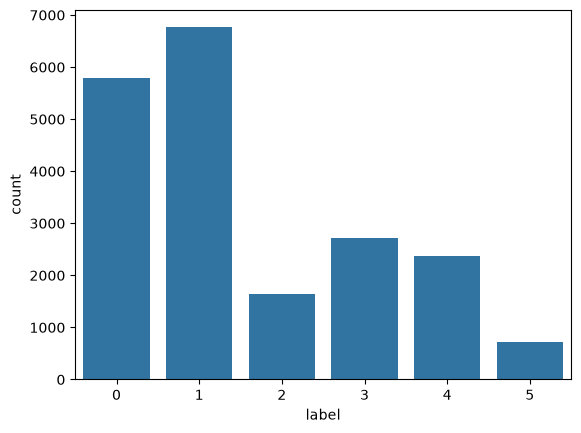

In [8]:
#분류문제에서는 label(원래 답) 의 균등함을 항상 확인해야함
#개수가 적은쪽의 것들을 맞추는 성능이 떨어지게 됨        
sns.countplot(x = 'label', data = data)
plt.show()


In [9]:
# 불필요한 단어(Stopwords & 구두점) 집합 준비
stop_words = set(stopwords.words("english"))
punctuations = set(string.punctuation)


# 전처리 함수
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stop_words and word not in punctuations]
    return tokens


# 데이터에 전처리 함수 적용
data["tokens"] = data["text"].apply(preprocess_text)
data.head()


,text,label,tokens
0,i didnt feel humiliated,0,"[didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,0,"[go, feeling, hopeless, damned, hopeful, aroun..."
2,im grabbing a minute to post i feel greedy wrong,3,"[im, grabbing, minute, post, feel, greedy, wrong]"
3,i am ever feeling nostalgic about the fireplac...,2,"[ever, feeling, nostalgic, fireplace, know, st..."
4,i am feeling grouchy,3,"[feeling, grouchy]"


In [10]:
all_words = [word for tokens in data["tokens"] for word in tokens]  #전체 단어 -> 중복될수있음
word_counts = Counter(all_words) #얼만큼 나올지 개수를 셈
print(word_counts) #각 단어의 횟수를 구할 때 쓰임 


Counter({'feel': 13938, 'feeling': 6431, 'like': 3616, 'im': 3055, 'really': 1182, 'know': 1080, 'time': 993, 'little': 932, 'get': 926, 'people': 839, 'want': 802, 'would': 798, 'still': 740, 'one': 739, 'think': 726, 'ive': 723, 'even': 717, 'life': 678, 'bit': 642, 'make': 639, 'something': 630, 'much': 618, 'love': 617, 'things': 607, 'going': 606, 'dont': 596, 'way': 571, 'could': 567, 'day': 540, 'back': 498, 'go': 493, 'pretty': 491, 'good': 481, 'need': 477, 'always': 453, 'right': 444, 'see': 440, 'also': 423, 'feelings': 419, 'feels': 416, 'say': 416, 'work': 407, 'today': 407, 'around': 382, 'cant': 376, 'made': 368, 'though': 365, 'got': 347, 'well': 344, 'didnt': 334, 'help': 334, 'never': 329, 'felt': 326, 'someone': 324, 'every': 311, 'days': 311, 'happy': 311, 'less': 308, 'quite': 305, 'makes': 303, 'sure': 302, 'enough': 295, 'many': 292, 'lot': 287, 'find': 283, 'anything': 276, 'away': 276, 'look': 272, 'home': 270, 'kind': 268, 'left': 268, 'better': 268, 'last': 2

In [11]:
vocab = {word: idx + 1 for idx, (word, _) in enumerate(word_counts.most_common())}
#vocab
#{key : value} 형태로 most common 제일 많이 나온것부터 []리스트로 나옴 -> 리스트로 나왔기 떄문에 enumerate 가능
# index와 mapping되서 나옴 -> idx + 1   

vocab["<PAD>"] = 0   # pad 길이 맞춰 주는거
vocab["<UNK>"] = len(vocab)  #unknown 알지 못하는 단어-> 불용어들이나올건데 지워 버렸기때문에 unknown들로 바꿔줌
print(f"어휘 집합 크기: {len(vocab)}")

#list 와 index -> len에는 값이 존재하지않는다


어휘 집합 크기: 16947


In [12]:
vocab['<PAD>']

0

In [ ]:
# def text_to_sequence(tokens):
#     return [vocab.get(word, vocab["<UNK>"]) for word in tokens]
# data["sequences"] = data["tokens"].apply(text_to_sequence)
# data[["text", "tokens", "sequences"]].head()


In [13]:
data["len"] = data["tokens"].apply(len) 
data.head()




,text,label,tokens,len
0,i didnt feel humiliated,0,"[didnt, feel, humiliated]",3
1,i can go from feeling so hopeless to so damned...,0,"[go, feeling, hopeless, damned, hopeful, aroun...",9
2,im grabbing a minute to post i feel greedy wrong,3,"[im, grabbing, minute, post, feel, greedy, wrong]",7
3,i am ever feeling nostalgic about the fireplac...,2,"[ever, feeling, nostalgic, fireplace, know, st...",7
4,i am feeling grouchy,3,"[feeling, grouchy]",2


95% 지점 20.0


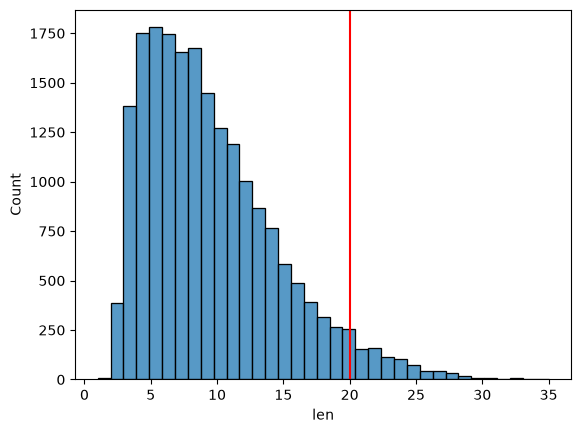

In [14]:
#문장 길이 분포에서 하위 95%에 해당하는 값 계산
p95 = np.percentile(data['len'], 95) #95%가 20자 안이라는 의미임. 
print('95% 지점', p95)
sns.histplot(x = 'len', data = data, bins = 35)
plt.axvline(p95, color = 'r')
plt.show()

In [15]:
# from keras.utils import pad_sequences
# max_len = 20
# sequences = pad_sequences(data["sequences"],
#                             maxlen=max_len,
#                             padding='post',
#                             truncating='post',
#                             value=vocab["<PAD>"])


In [16]:
# 토큰(단어) 리스트를 vocab의 정수 인덱스 리스트로 변환
# vocab에 없는 단어(불용어 등으로 지워지지 않았지만 사전에 없는 경우)는 <UNK> 인덱스로 대체
data["sequences"] = data["tokens"].apply(
    lambda tokens: [vocab.get(word, vocab["<UNK>"]) for word in tokens]
)
data[["tokens", "sequences"]].head()

,tokens,sequences
0,"[didnt, feel, humiliated]","[50, 1, 510]"
1,"[go, feeling, hopeless, damned, hopeful, aroun...","[31, 2, 408, 2987, 431, 44, 54, 1565, 1252]"
2,"[im, grabbing, minute, post, feel, greedy, wrong]","[4, 2988, 1100, 183, 1, 381, 308]"
3,"[ever, feeling, nostalgic, fireplace, know, st...","[78, 2, 561, 4628, 6, 13, 3363]"
4,"[feeling, grouchy]","[2, 918]"


In [17]:
def pad_sequences_torch(sequences, maxlen, padding='post', truncating='post', value=0):
    result = np.full((len(sequences), maxlen), value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        if len(seq) == 0:
            continue
        if truncating == 'post':
            seq = seq[:maxlen]
        else:
            seq = seq[-maxlen:]
        if padding == 'post':
            result[i, :len(seq)] = seq
        else:
            result[i, -len(seq):] = seq
    return result


max_len = 20
sequences = pad_sequences_torch(data["sequences"],
                                maxlen=max_len,
                                padding='post',
                                truncating='post',
                                value=vocab["<PAD>"])


In [18]:
print(sequences[:10])

[[  50    1  510    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0]
 [  31    2  408 2987  431   44   54 1565 1252    0    0    0    0    0    0    0    0    0    0    0]
 [   4 2988 1100  183    1  381  308    0    0    0    0    0    0    0    0    0    0    0    0    0]
 [  78    2  561 4628    6   13 3363    0    0    0    0    0    0    0    0    0    0    0    0    0]
 [   2  918    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0]
 [  16    2    8  454  207  218   61    0    0    0    0    0    0    0    0    0    0    0    0    0]
 [  16  233 8278   98 8279  748   16 2698 1394   64 1725   38    1    3  298    0    0    0    0    0]
 [   1  342   18 1814  696   91  168  257    0    0    0    0    0    0    0    0    0    0    0    0]
 [5826  122    1 5826 5827   49   46  893 4629    0    0    0    0    0    0    0    0    0    0    0]
 [   1  540    0    0    0    0    0    0    0    0    0    0    0    0  

In [19]:
x = np.array(sequences)
y = np.array(data["label"])
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.2)
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


In [ ]:
class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size):
        super(SimpleLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)  #임베딩해주는 코드가 있음 -> vocab_size 가 들어가야함, 
        #embedding.dim -> 한개단어의 정수 인덱스값을 몇개의 벡터로 변환할지 지정할지
        #embedding dim의 개수가 크면 w의 크기가 커진다
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        #hidden_size: 출력결과를 저장할 벡터의 길이 =
        #batch_size를 앞으로 보내야된다
        #batch_first= True지정 안하면 (seq_len, batch, feature) => dataloader가 (batch, 
        # , feature) 로 받기 떄문
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x): #X: 신경망에 한번(batch_size)에 입력되는 값 => batch size = 32, seq_len = 20 (문장 길이)
        #정수 인덱스가 embedding하기 전에 들어가야됨  x-> (32, 20)
        x = self.embedding(x) # x -> 32 X 20 X 100(embedding_dim)
        _, (hidden, _) = self.lstm(x) # lstm 출력 : (output, (h_n, c_n))  -> h_n(hidden)만 받겠다    (lstn은 3개의 output이 나옴)
        #h_n: 마지막 시점의 은닉 상태 -> 3차원으로 나옴  (1, 32, 128) <- 1장
        out = self.fc(hidden[-1]) #1장을 뽑으라는 의미 (32, 128)
        return out #6진분류니까 6을 out 함 --> (32, 6)  batch size 32는 계속 유지됨


In [ ]:
vocab_size = len(vocab)  #16946
embedding_dim = 100  #내맘대로
hidden_size = 128 #내맘대로
output_size = 6 
learning_rate = 0.001 #내맘대로 (hyperparmaeters)


model = SimpleLSTMClassifier(vocab_size, embedding_dim, hidden_size, output_size).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Epoch 1, train loss : 1.584901, val loss : 1.568545
Epoch 2, train loss : 1.488503, val loss : 1.226538
Epoch 3, train loss : 0.964298, val loss : 0.655729
Epoch 4, train loss : 0.394666, val loss : 0.390950
Epoch 5, train loss : 0.176462, val loss : 0.321312
Epoch 6, train loss : 0.101945, val loss : 0.355120
Epoch 7, train loss : 0.066774, val loss : 0.398704
Epoch 8, train loss : 0.055089, val loss : 0.397123
Epoch 9, train loss : 0.043039, val loss : 0.401198
Epoch 10, train loss : 0.033580, val loss : 0.425099


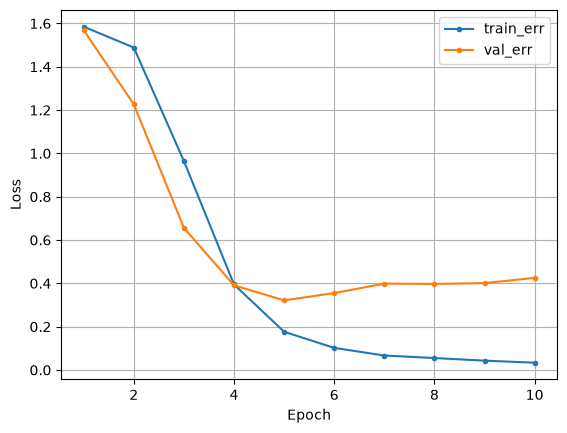

In [ ]:
#학습    val만 성능 ㄸ러어짐 -> 과적합
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")


dl_learning_curve(tr_loss_list, val_loss_list)


In [24]:
# 예측
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
print(type(pred))
pred = pred.softmax(dim = 1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)


<class 'torch.Tensor'>


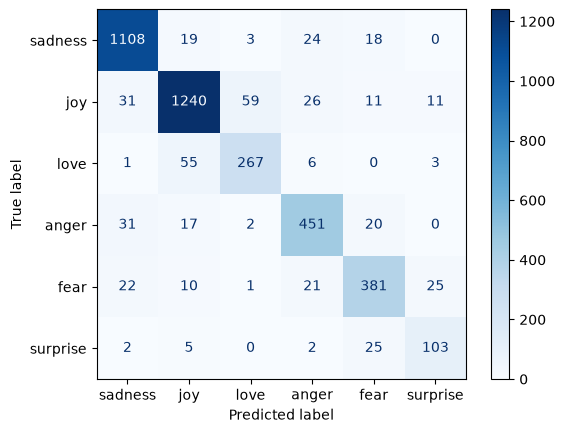

----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

     sadness       0.93      0.95      0.94      1172
         joy       0.92      0.90      0.91      1378
        love       0.80      0.80      0.80       332
       anger       0.85      0.87      0.86       521
        fear       0.84      0.83      0.83       460
    surprise       0.73      0.75      0.74       137

    accuracy                           0.89      4000
   macro avg       0.84      0.85      0.85      4000
weighted avg       0.89      0.89      0.89      4000



In [ ]:
# confusion matrix 시각화
#confusion matrix 사용 효과: 틀린부분/왜틀렸는지를 확인할수있는 matrix 가 될수있음
      
#label 불균형 중에 수가 적었던걸들의 accuracy 가 적게 나옴 -> 불균형 처리를 하고 들어가는게 성능을 높일 수 있었ㄸ아.
label_list = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
cm = confusion_matrix(y_val_ts.cpu().numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_list)
disp.plot(cmap="Blues")
plt.show()
print('-'*100)


# classification_report
print(classification_report(y_val_ts.cpu().numpy(), pred, target_names=label_list))
